## Model-Based Segmentation, Supervised

### Prelude

#### Installs and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pip install scikit-image

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [5]:
# %pip install focal-loss

In [3]:
%pip install -U albumentations --no-binary qudida,albumentations

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 173 kB 29.8 MB/s 
Skipping wheel build for albumentations, due to binaries being disabled for it.
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.2.1
    Uninstalling albumentations-1.2.1:
      Successfully uninstalled albumentations-1.2.1
    Running setup.py install for albumentations ... done


In [4]:
%pip install segmentation-models

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 50 kB 2.6 MB/s 


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A

import segmentation_models as sm
sm.set_framework('tf.keras')
sm.framework()

import matplotlib.pyplot as  plt
from matplotlib.gridspec import GridSpec

from glob import glob
from random import randint
from skimage.io import imread
from datetime import datetime 
# from focal_loss import SparseCategoricalFocalLoss

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose
from tensorflow.keras.layers import  BatchNormalization, Dropout, Lambda, Activation, SeparableConv2D, AveragePooling2D

Segmentation Models: using `keras` framework.


#### Path Assignment

In [3]:
# root_dir = '../data/external'
root_dir = '/content/drive/MyDrive/ModelBasedSegmentation/data/external'
img_path_list = glob(os.path.join(root_dir, 'images/**/*.jpg'))
mask_path_list = [path.replace('images', 'annotations').replace('.jpg', '_mask.png') for path in img_path_list]

In [4]:
path_df = pd.DataFrame({'Img Path': img_path_list, 'Mask Path': mask_path_list})

train_df, test_df = train_test_split(path_df, test_size=0.1, shuffle=False)
train_df, val_df = train_test_split(train_df, test_size=0.2, shuffle=False)

#### Helper Functions

In [5]:
def Patch(img, patch_size):
    patchs = []
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patchs.append(patch)
    return np.array(patchs)


def Unpatch(patchs, img_shape):
    row_range = img_shape[0]//patchs.shape[1]
    clmn_range = img_shape[1]//patchs.shape[2]
    patchs_ = np.reshape(patchs, (row_range, clmn_range, *patchs.shape[1:]))

    clmn_stacks = []
    for r_patchs in patchs_:
        clmn_stacks.append(np.concatenate(r_patchs, axis=1))
    return np.concatenate(clmn_stacks, axis=0)


def Normalize(img):
    Scaler = MinMaxScaler()
#     flat_img = img.reshape((-1))
    flat_img = img.reshape((-1, 3))  # MinMaxScaler requires 2D array
    normalized_img = Scaler.fit_transform(flat_img) # 0-255 to 0-1
    normalized_img = normalized_img.reshape(img.shape)
    return normalized_img


def EncodeLabel(mask, n_classes=3, to_catagorical=True): # Encode mask either with one hot encoding or with integer encoding
    mask_1chnl = np.sum(mask, axis=-1)
    mask_flat = mask_1chnl.reshape((-1))

    Encoder = LabelEncoder()
    encoded_mask = Encoder.fit_transform(mask_flat) # [0 176 255] to [0 1 2]
    encoded_mask = encoded_mask.reshape(mask_1chnl.shape)
    if to_catagorical:
        encoded_mask = to_categorical(encoded_mask, num_classes=n_classes, dtype='int8')
    return encoded_mask

def EncodeSparseLabel(mask, n_classes=3):
    mask_flat = mask.reshape((-1))

    Encoder = LabelEncoder()
    encoded_mask = Encoder.fit_transform(mask_flat) # [0 176 255] to [0 1 2]
    encoded_mask = encoded_mask.reshape(mask.shape)
    return encoded_mask.astype('float32')


def EncodeCatLabel(mask, n_classes=3):
    n_classes = len(np.unique(mask)) if n_classes==None else n_classes
    mask_1chnl = np.sum(mask, axis=-1)
    
    cat_encoded = np.zeros(shape=(*mask_1chnl.shape, n_classes))

    for i, value in enumerate(np.unique(mask_1chnl)):
        cat_encoded[mask_1chnl==value, i] = 1     
    return cat_encoded.astype('float32')


def DecodePrediction(pred):
  argmax_idx = np.array([np.argmax(x) for x in pred.reshape((-1, 3))])
  argmax_idx[argmax_idx==0] = 0
  argmax_idx[argmax_idx==1] = 176
  argmax_idx[argmax_idx==2] = 255

  # decoded_mask = argmax_idx.reshape((*pred.shape[:-1], 1))
  decoded_mask = argmax_idx.reshape(pred.shape[:-1])
  return decoded_mask.astype('uint8')


def ComputeIoU(pred_mask, true_mask):

    # convert to one channel
    pred_1chnl = np.sum(pred_mask, axis=-1) if len(pred_mask.shape)==3 else pred_mask
    true_1chnl = np.sum(true_mask, axis=-1) if len(true_mask.shape)==3 else true_mask

    # encode the unique label values of a flat array to 0,...,n_class-1 
    encoder = LabelEncoder()    

    true_flat = true_1chnl.reshape((-1))
    true_encoded = encoder.fit_transform(true_flat)
    true_encoded = true_encoded.reshape(true_1chnl.shape)

    cls_lbl = encoder.classes_  
    
    pred_flat = pred_1chnl.reshape((-1))
    pred_encoded = encoder.fit_transform(pred_flat)
    pred_encoded = pred_encoded.reshape(pred_1chnl.shape)

    iou = []
    for value in np.unique(true_encoded):
        true_binarized = np.where(true_encoded==value, 1, 0)
        pred_binarized = np.where(pred_encoded==value, 1, 0)

        intersection = np.sum(np.multiply(true_binarized, pred_binarized)) 
        union = np.sum(pred_binarized) + np.sum(true_binarized) - intersection
        iou.append(intersection/union)

    return list(cls_lbl), iou

#### Visualize Image Patching and Unpatching

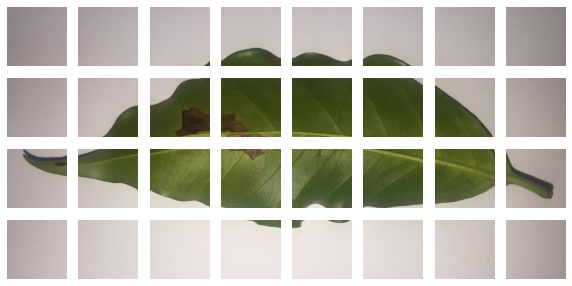

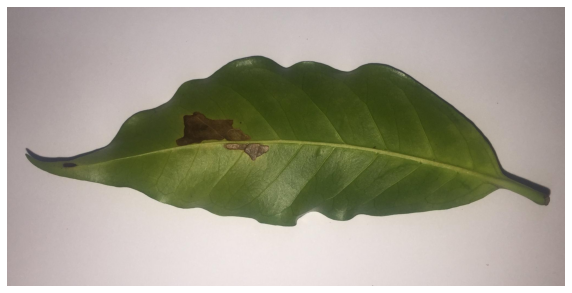

In [10]:
idx = randint(0, len(img_path_list))
patch_size=256

img = cv2.cvtColor(cv2.imread(img_path_list[idx]), cv2.COLOR_BGR2RGB)

patched_img = Patch(img, patch_size)
unpatched_img = Unpatch(patched_img, img.shape)

ncols, nrows = img.shape[1]//patch_size, img.shape[0]//patch_size

gs = GridSpec(nrows, ncols)
fig1 = plt.figure(figsize=(10, 5))
for r in range(nrows):
    for c in range(ncols):
        ax = fig1.add_subplot(gs[r, c])
        ax.imshow(patched_img[(r*ncols+c)])
        ax.axis('off')

plt.figure(figsize=(10, 6))
plt.imshow(unpatched_img)
plt.axis('off')

plt.show()

#### Custom Data Generator

In [6]:
class DataGenerator(Sequence):

    def __init__(self, df, patch_size, preprocessor, shuffle=False, encode_mask=True):
        self.df = df.copy()
        self.patch_size = patch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.preprocessor = preprocessor
        self.encode_mask = encode_mask

        self.on_epoch_end()

    def __len__(self):
      return (1024 * 2048) // (self.patch_size ** 2)                             # the number patches extracted from 1024 by 2048 image


    def on_epoch_end(self):
        if self.shuffle == True:
            np.random.shuffle(self.indexes)
            return self.df.reindex(self.indexes)   
    
    def __getitem__(self, index):
        index = index - 1
        img_path = self.df['Img Path'].iloc[index]
        mask_path = self.df['Mask Path'].iloc[index]

        img, mask = imread(img_path), imread(mask_path)                          # loads rgb image
        
        transform = A.Compose([A.RandomBrightnessContrast(p=0.25),
                              #  A.HorizontalFlip(p=0.25),
                              #  A.VerticalFlip(p=0.25),
                               A.Blur(p=0.25)])

        augmented = transform(image=img, mask=mask)
        augmented_img, augmented_mask = augmented['image'], augmented['mask']

        processed_img = self.preprocessor(augmented_img)                         # processing image as per the model requirement        
        patched_img = Patch(processed_img, self.patch_size)
        
        if self.encode_mask:
          encoded_mask = EncodeCatLabel(augmented_mask)
          patched_mask = Patch(encoded_mask, self.patch_size)
        else:
          patched_mask = Patch(augmented_mask, self.patch_size) 
       
        return patched_img, patched_mask

#### Custom Metrics and Losses

In [12]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)


def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

def jacard_coef_loss(y_true, y_pred):
    return -jacard_coef(y_true, y_pred)

### Segmenatation Using Vanilla UNet

#### Vanilla Unet Model

In [15]:
def ConvBlock(input, n_filters, set_batchnorm, dropout):
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(input)
    if set_batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
    if set_batchnorm:
        x = BatchNormalization()(x)    
    x = Activation('relu')(x)
    if dropout > 0:
        x = Dropout(dropout)(x)
    return x

def EncoderBlock(input, n_filters, set_batchnorm, dropout):
    x = ConvBlock(input, n_filters, set_batchnorm, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, n_filters, set_batchnorm, dropout):
    x = Conv2DTranspose(n_filters, (2, 2), strides=2, padding='same')(input)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, set_batchnorm, dropout)
    return x


def Unet(input_shape, n_classes, n_filters, set_batchnorm, dropout):
    inputs = Input(input_shape)

    conv1, pool1 = EncoderBlock(inputs, n_filters, set_batchnorm, dropout)
    conv2, pool2 = EncoderBlock(pool1, n_filters*2, set_batchnorm, dropout)
    conv3, pool3 = EncoderBlock(pool2, n_filters*4, set_batchnorm, dropout)
    conv4, pool4 = EncoderBlock(pool3, n_filters*8, set_batchnorm, dropout)

    midconv = ConvBlock(pool4, n_filters*16, set_batchnorm, dropout) # Bottleneck layer

    deconv1 = DecoderBlock(midconv, conv4, n_filters*8, set_batchnorm, dropout)
    deconv2 = DecoderBlock(deconv1, conv3, n_filters*4, set_batchnorm, dropout)
    deconv3 = DecoderBlock(deconv2, conv2, n_filters*2, set_batchnorm, dropout)
    deconv4 = DecoderBlock(deconv3, conv1, n_filters, set_batchnorm, dropout)

    outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(deconv4)

    model = Model(inputs, outputs, name='Vanilla_UNet')
    return model

In [16]:
model_vanilla = Unet(input_shape=(256, 256, 3), n_classes=3, n_filters=64, set_batchnorm=False, dropout=0.2)
model_vanilla.summary()

Model: "Vanilla_UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 activation (Activation)        (None, 256, 256, 64  0           ['conv2d[0][0]']                 
                                )                                                      

#### Compile and Train

In [115]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=64,
                               decay_rate=0.98,
                               staircase=True)
 
model_vanilla.compile(loss='categorical_crossentropy',
                      optimizer= Adam(learning_rate=lr_schedule),
                      metrics=['accuracy'])

In [116]:
train_generator = DataGenerator(df=train_df, patch_size=256, shuffle=True, preprocessor=Normalize)
val_generator   = DataGenerator(df=val_df, patch_size=256, shuffle=True, preprocessor=Normalize)
test_generator  = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=Normalize)

In [114]:
!rm -rf /content/drive/MyDrive/ModelBasedSegmentation/Checkpoints
!rm -rf /content/drive/MyDrive/ModelBasedSegmentation/SavedModel

In [117]:
num_epochs = 50
check_point = ModelCheckpoint(filepath='/content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/VanillaUnet',
                              monitor='val_loss',
                              verbose=1,
                              save_best_only=True,
                              save_freq='epoch')
                              
early_stop = EarlyStopping(min_delta=0.001,
                           monitor='val_loss',
                           patience=10,
                           verbose=1)
                           
start = datetime.now()

hist_vanilla= model_vanilla.fit(x=train_generator,
                                epochs = num_epochs,
                                verbose=2,
                                validation_data = val_generator,
                                callbacks = [check_point, early_stop])

stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model_vanilla.save('/content/drive/MyDrive/ModelBasedSegmentation/SavedModel/VanillaUnet')                           

Epoch 1/50

Epoch 1: val_loss improved from inf to 0.02312, saving model to /content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/VanillaUnet


32/32 - 81s - loss: 0.0544 - accuracy: 0.9849 - val_loss: 0.0231 - val_accuracy: 0.9943 - 81s/epoch - 3s/step
Epoch 2/50

Epoch 2: val_loss did not improve from 0.02312
32/32 - 72s - loss: 0.0494 - accuracy: 0.9869 - val_loss: 0.0248 - val_accuracy: 0.9938 - 72s/epoch - 2s/step
Epoch 3/50

Epoch 3: val_loss did not improve from 0.02312
32/32 - 72s - loss: 0.0419 - accuracy: 0.9884 - val_loss: 0.0272 - val_accuracy: 0.9926 - 72s/epoch - 2s/step
Epoch 4/50

Epoch 4: val_loss improved from 0.02312 to 0.02289, saving model to /content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/VanillaUnet


32/32 - 78s - loss: 0.0464 - accuracy: 0.9870 - val_loss: 0.0229 - val_accuracy: 0.9940 - 78s/epoch - 2s/step
Epoch 4: early stopping
Execution time: 0:05:03.455938


#### Visualizing Training Results

In [ ]:
hist_vanilla.history.keys()

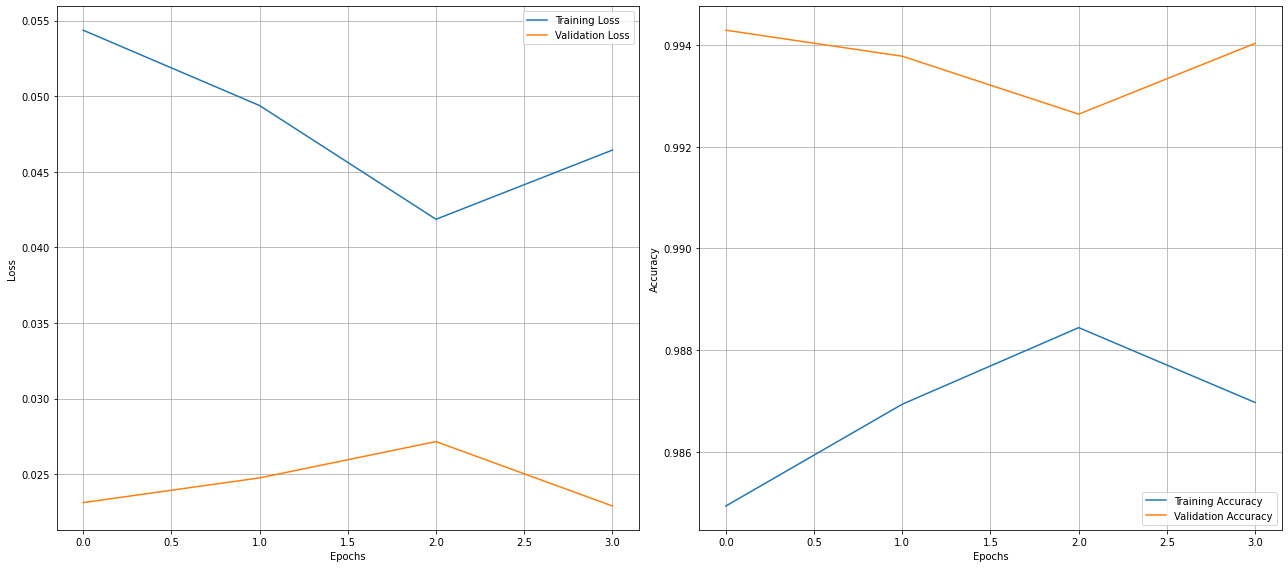

In [118]:
loss, accuracy, val_loss, val_accuracy = hist_vanilla.history.values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.plot(loss, label='Training Loss')
ax1.plot(val_loss, label='Validation Loss')
ax1.set(ylabel='Loss', xlabel='Epochs' )
ax1.legend(loc='upper right')
ax1.grid()

ax2.plot(accuracy, label='Training Accuracy')
ax2.plot(val_accuracy, label='Validation Accuracy')
ax2.set(ylabel='Accuracy', xlabel='Epochs' )
ax2.legend(loc='lower right')
ax2.grid()

plt.tight_layout()
plt.show()

#### Evaluate Model

In [119]:
loss, acc = model_vanilla.evaluate(test_generator, verbose=0)
print(f'    Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')

    Test Loss: 0.0361
Test Accuracy: 98.99%


#### Prediction and Result

In [ ]:
pred_vanilla = model_vanilla.predict(x=test_generator, verbose=1)

In [121]:
decoded_pred = DecodePrediction(pred_vanilla)

In [123]:
unpatched_preds = []
for idx in range(0, 1024, 32):
  unpatched_img = Unpatch(decoded_pred[idx:idx+32], (1024, 2048))
  unpatched_preds.append(unpatched_img)
unpatched_preds = np.array(unpatched_preds)

np.save('/content/drive/MyDrive/ModelBasedSegmentation/PredictedMasks/Vanilla.npy', unpatched_preds)

#### Visualizing Predictions

In [ ]:
test_generator = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=Normalize, encode_mask=False)

unpatched_img = np.zeros(shape=(32, 1024, 2048, 3))
unpatched_mask = np.zeros(shape=(32, 1024, 2048, 3))

for i, (img, mask) in enumerate(list(test_generator)):
  unpatched_img[i] = Unpatch(img, (1024, 2048))
  unpatched_mask[i]= Unpatch(mask, (1024, 2048))

In [ ]:
unpatched_preds = np.load('/content/drive/MyDrive/ModelBasedSegmentation/PredictedMasks/Vanilla.npy')

In [ ]:
for idx in range(2):
  img = unpatched_img[idx]
  mask = unpatched_mask[idx]
  mask_1chnl = np.sum(mask, axis=-1).astype('uint8')
  pred_mask_ = unpatched_preds[idx]

  misclassified = cv2.bitwise_xor(pred_mask_, mask_1chnl)

  _, iou = ComputeIoU(pred_mask_, mask_1chnl)   
  label = f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f} \n Symptom IoU:  {iou[2]: .3f}' if len(iou) == 3 else \
          f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f}'

  imgs =  [img, mask_1chnl, pred_mask_, misclassified]
  titles = ['Original Image', 'True Mask', 'Predicted Mask', 'Misclassified Pixels']  
  subplot_idx = np.arange(4) + 141

  plt.figure(figsize=(30, 20))
  for i, (img, idx, title) in enumerate(zip(imgs, subplot_idx, titles)):
    plt.subplot(idx)
    plt.imshow(img)
    plt.title(title), plt.xticks([]), plt.yticks([])

    if i == 3:
      plt.xlabel(label)

### Segmentation Using DeepLabV3+

#### DeepLabV3+ Model

In [165]:
def convolution_block(block_input, num_filters=256, kernel_size=3, dilation_rate=1, padding='same', use_bias=False):
    x = Conv2D(num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='same', use_bias=use_bias, kernel_initializer='he_normal')(block_input)
    x = BatchNormalization()(x)
    return Activation('relu')(x)


def DilatedSpatialPyramidPooling(dspp_input):
    dims = dspp_input.shape
    x = AveragePooling2D(pool_size=(dims[-3], dims[-2]))(dspp_input)
    x = convolution_block(x, kernel_size=1, use_bias=True)
    out_pool = UpSampling2D(size=(dims[-3] // x.shape[1], dims[-2] // x.shape[2]), interpolation='bilinear')(x)

    out_1 = convolution_block(dspp_input, kernel_size=1, dilation_rate=1)
    out_6 = convolution_block(dspp_input, kernel_size=3, dilation_rate=6)
    out_12 = convolution_block(dspp_input, kernel_size=3, dilation_rate=12)
    out_18 = convolution_block(dspp_input, kernel_size=3, dilation_rate=18)

    x = concatenate([out_pool, out_1, out_6, out_12, out_18], axis=-1)
    output = convolution_block(x, kernel_size=1)
    return output

def DeeplabV3Plus(image_size, num_classes):
    model_input = Input(shape=(image_size, image_size, 3))
    resnet50 = ResNet50(weights='imagenet', include_top=False, input_tensor=model_input)
    x = resnet50.get_layer('conv4_block6_2_relu').output
    x = DilatedSpatialPyramidPooling(x)

    input_a = UpSampling2D(size=(image_size // 4 // x.shape[1], image_size // 4 // x.shape[2]), interpolation='bilinear')(x)
    input_b = resnet50.get_layer('conv2_block3_2_relu').output
    input_b = convolution_block(input_b, num_filters=48, kernel_size=1)

    x = concatenate([input_a, input_b], axis=-1)
    x = convolution_block(x)
    x = convolution_block(x)
    x = UpSampling2D(size=(image_size // x.shape[1], image_size // x.shape[2]), interpolation='bilinear')(x)
    model_output = Conv2D(num_classes, kernel_size=(1, 1), padding='same', activation='softmax')(x)
    return Model(inputs=model_input, outputs=model_output)

In [167]:
model_dplb = DeeplabV3Plus(image_size=256, num_classes=3)
model_dplb.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 262, 262, 3)  0           ['input_13[0][0]']               
                                                                                                  
 conv1_conv (Conv2D)            (None, 128, 128, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

#### Compile and Train

In [168]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=64,
                               decay_rate=0.98,
                               staircase=True)
 
model_dplb.compile(loss='categorical_crossentropy',
              optimizer= Adam(learning_rate=lr_schedule),
              metrics=['accuracy'])

In [49]:
train_generator = DataGenerator(df=train_df, patch_size=256, shuffle=True, preprocessor=Normalize)
val_generator = DataGenerator(df=val_df, patch_size=256, shuffle=True, preprocessor=Normalize)
test_generator = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=Normalize)

In [ ]:
num_epochs = 50
check_point = ModelCheckpoint(filepath='/content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/DeepLabV3Plus',
                              monitor='val_loss',
                              verbose=1,
                              save_best_only=True,
                              save_freq='epoch')
                              
early_stop = EarlyStopping(min_delta=0.001,
                           monitor='val_loss',
                           patience=10,
                           verbose=1)
                           
start = datetime.now()

hist_dplb = model_dplb.fit(x=train_generator,
                 epochs = num_epochs,
                 verbose=2,
                 validation_data = val_generator,
                 callbacks = [check_point, early_stop])

stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model_dplb.save('/content/drive/MyDrive/ModelBasedSegmentation/SavedModel/DeepLabV3Plus')                           

#### Visualizing Training Results


In [ ]:
hist_dplb.history.key()

In [ ]:
loss, accuracy, val_loss, val_accuracy = hist_dplb.history.values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.plot(loss, label='Training Loss')
ax1.plot(val_loss, label='Validation Loss')
ax1.set(ylabel='Loss', xlabel='Epochs' )
ax1.legend(loc='upper right')
ax1.grid()

ax2.plot(accuracy, label='Training Accuracy')
ax2.plot(val_accuracy, label='Validation Accuracy')
ax2.set(ylabel='Accuracy', xlabel='Epochs')
ax2.legend(loc='lower right')
ax2.grid()

plt.tight_layout()
plt.show()

#### Evaluate Model

In [ ]:
loss, acc = model_dplb.evaluate(test_generator, verbose=0)
print(f'    Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')

#### Prediction and Result

In [ ]:
pred_dplb = model_dplb.predict(x=test_generator, verbose=1)

In [ ]:
decoded_pred = DecodePrediction(pred_dplb)

In [ ]:
unpatched_pred = []
for idx in range(0, 1024, 32):
  unpatched_img = Unpatch(decoded_pred[idx:idx+32], (1024, 2048))
  unpatched_pred.append(unpatched_img)
unpatched_pred = np.array(unpatched_pred)

np.save('/content/drive/MyDrive/ModelBasedSegmentation/PredictedMasks/DeepLabV3Plus.npy', unpatched_pred)

#### Visualizing Predictions

In [7]:
test_generator = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=Normalize, encode_mask=False)

unpatched_img = np.zeros(shape=(32, 1024, 2048, 3))
unpatched_mask = np.zeros(shape=(32, 1024, 2048, 3))

for i, (img, mask) in enumerate(list(test_generator)):
  unpatched_img[i] = Unpatch(img, (1024, 2048))
  unpatched_mask[i]= Unpatch(mask, (1024, 2048))

In [8]:
unpatched_pred = np.load('/content/drive/MyDrive/ModelBasedSegmentation/PredictedMasks/DeepLabV3Plus.npy')

[0.9976781320944529, 0.8304871525159213, 0.26929467838558746]
[0.9945936368181137, 0.987602143512184]


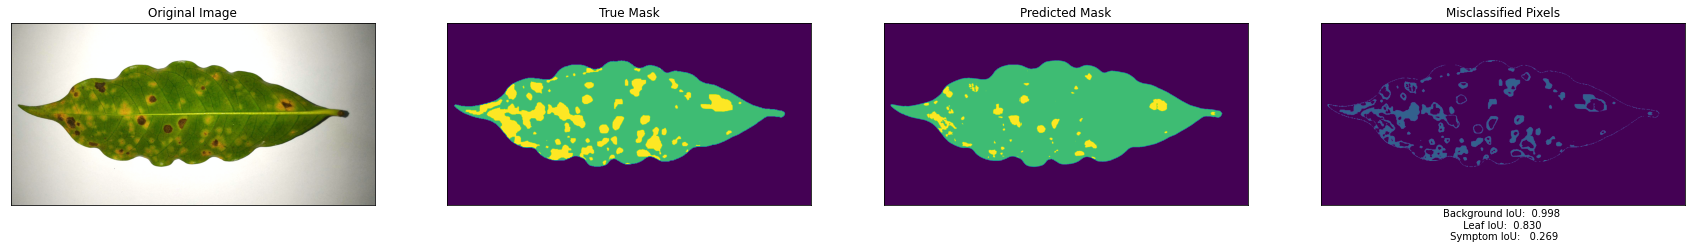

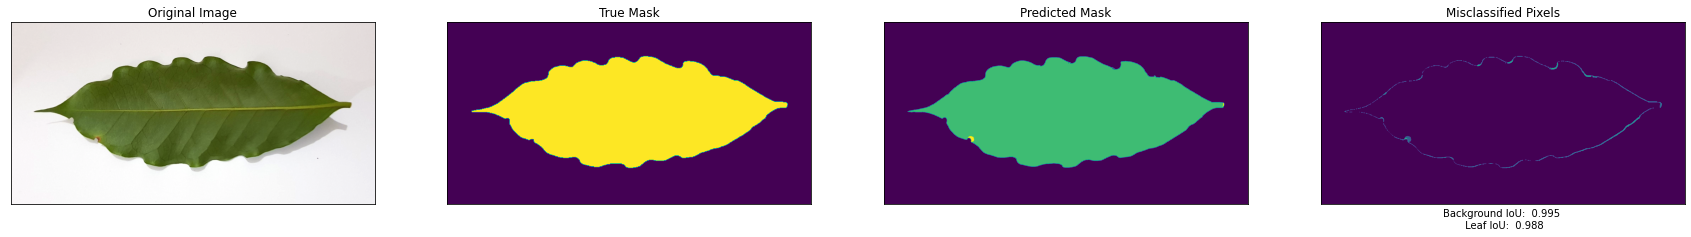

In [32]:
for idx in range(2):
  img = unpatched_img[idx]
  mask = unpatched_mask[idx]
  mask_1chnl = np.sum(mask, axis=-1).astype('uint8')
  pred_mask_ = unpatched_pred[idx]

  misclassified = cv2.bitwise_xor(pred_mask_, mask_1chnl)

  _, iou = ComputeIoU(pred_mask_, mask_1chnl)   
  label = f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f} \n Symptom IoU:  {iou[2]: .3f}' if len(iou) == 3 else \
          f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f}'

  imgs =  [img, mask_1chnl, pred_mask_, misclassified]
  titles = ['Original Image', 'True Mask', 'Predicted Mask', 'Misclassified Pixels']  
  subplot_idx = np.arange(4) + 141

  plt.figure(figsize=(30, 20))
  for i, (img, idx, title) in enumerate(zip(imgs, subplot_idx, titles)):
    plt.subplot(idx)
    plt.imshow(img)
    plt.title(title), plt.xticks([]), plt.yticks([])
    if i == 3:
      plt.xlabel(label)

### Segmentation Using Segmentation Models

#### The Model

In [133]:
BACKBONE = 'mobilenetv2'
model_sm = sm.Unet(BACKBONE, classes=3, input_shape=(256, 256, 3),  activation='softmax', encoder_weights='imagenet')
model_sm.summary()

9420800/9406464 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1_pad (ZeroPadding2D)      (None, 257, 257, 3)  0           ['input_8[0][0]']                
                                                                                                  
 Conv1 (Conv2D)                 (None, 128, 128, 32  864         ['Conv1_pad[0][0]']              
                                )                                                                 
                               

#### Compile and Train

In [138]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=64,
                               decay_rate=0.98,
                               staircase=True)

model_sm.compile(loss=sm.losses.categorical_focal_dice_loss,
                 optimizer= Adam(learning_rate=lr_schedule),
                 metrics=[sm.metrics.iou_score])

In [136]:
preprocess_input = sm.get_preprocessing(BACKBONE)
train_generator = DataGenerator(df=train_df, patch_size=256, shuffle=True, preprocessor=preprocess_input)
val_generator   = DataGenerator(df=val_df, patch_size=256, shuffle=True, preprocessor=preprocess_input)
test_generator  = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=preprocess_input)

In [150]:
!rm -rf /content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/SegmentationModelsUnet
!rm -rf /content/drive/MyDrive/ModelBasedSegmentation/SavedModel/SegmentationModelsUnet

In [ ]:
num_epochs = 50
check_point = ModelCheckpoint(filepath='/content/drive/MyDrive/ModelBasedSegmentation/Checkpoints/SegmentationModelsUnet',
                              monitor='val_loss',
                              verbose=1,
                              save_best_only=True,
                              save_freq='epoch')
                              
early_stop = EarlyStopping(min_delta=0.001,
                           monitor='val_loss',
                           patience=10,
                           verbose=1)
                           
start = datetime.now()

hist_sm = model_sm.fit(x=train_generator,
                       epochs = num_epochs,
                       verbose=2,
                       validation_data = val_generator,
                       callbacks = [check_point, early_stop])

stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model_sm.save('/content/drive/MyDrive/ModelBasedSegmentation/SavedModel/SegmentationModelsUnet')                           

#### Visualizing Training Results

In [149]:
hist_sm.history.keys()

dict_keys(['loss', 'iou_score', 'val_loss', 'val_iou_score'])


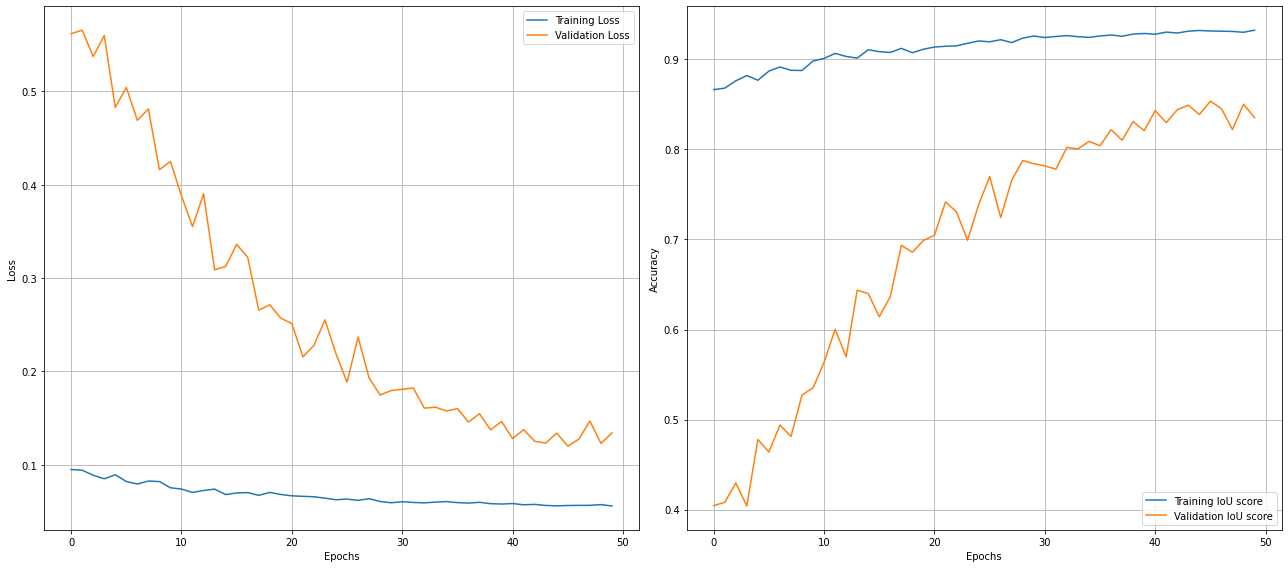

In [155]:
loss, accuracy, val_loss, val_accuracy = hist_sm.history.values()                      

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.plot(loss, label='Training Loss')
ax1.plot(val_loss, label='Validation Loss')
ax1.set(ylabel='Loss', xlabel='Epochs' )
ax1.legend(loc='upper right')
ax1.grid()

ax2.plot(accuracy, label='Training IoU score')
ax2.plot(val_accuracy, label='Validation IoU score')
ax2.set(ylabel='Accuracy', xlabel='Epochs' )
ax2.legend(loc='lower right')
ax2.grid()

plt.tight_layout()
plt.show()

#### Evaluate Model

In [157]:
loss, acc = model_sm.evaluate(test_generator, verbose=0)
print(f'    Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')

    Test Loss: 0.1658
Test Accuracy: 80.29%


#### Prediction and Result

In [ ]:
pred_sm = model_sm.predict(x=test_generator, verbose=1)

In [ ]:
decoded_pred = DecodePrediction(pred_sm)

In [ ]:
unpatched_pred = []
for idx in range(0, 1024, 32):
  unpatched_img = Unpatch(decoded_pred[idx:idx+32], (1024, 2048))
  unpatched_pred.append(unpatched_img)
unpatched_decoded_pred = np.array(unpatched_pred)

np.save('/content/drive/MyDrive/ModelBasedSegmentation/PredictedMasks/SegmentationModelsUnet.npy',unpatched_pred)

#### Visualizing Predictions

In [ ]:
test_generator = DataGenerator(df=test_df, patch_size=256, shuffle=True, preprocessor=preprocess_input, encode_mask=False)

unpatched_img = np.zeros(shape=(32, 1024, 2048, 3))
unpatched_mask = np.zeros(shape=(32, 1024, 2048, 3))

for i, (img, mask) in enumerate(list(test_generator)):
  unpatched_img[i] = Unpatch(img, (1024, 2048))
  unpatched_mask[i]= Unpatch(mask, (1024, 2048))

In [ ]:
unpatched_pred = np.load('/content/drive/MyDrive/ModelBasedSegmentation/unpatched_decoded_pred_2.npy')

In [ ]:
for idx in range(2):
  img = unpatched_img[idx]
  mask = unpatched_mask[idx]
  mask_1chnl = np.sum(mask, axis=-1).astype('uint8')
  pred_mask_ = unpatched_decoded_pred[idx]

  misclassified = cv2.bitwise_xor(pred_mask_, mask_1chnl)

  _, iou = ComputeIoU(pred_mask_, mask_1chnl)   
  label = f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f} \n Symptom IoU:  {iou[2]: .3f}' if len(iou) == 3 else \
          f'Background IoU: {iou[0]: .3f} \n Leaf IoU: {iou[1]: .3f}'


  imgs =  [img, mask_1chnl, pred_mask_, misclassified]
  subplot_idx = np.arange(4) + 141

  titles = ['Original Image', 'True Mask', 'Predicted Mask', 'Misclassified Pixels']  

  plt.figure(figsize=(30, 20))
  for i, (img, idx, title) in enumerate(zip(imgs, subplot_idx, titles)):
    plt.subplot(idx)
    plt.imshow(img)
    plt.title(title)
    plt.xticks([]), plt.yticks([])

    if i == 3:
      plt.xlabel(label)

## Model Based Segmentation, Unsupervised

#### WNet Model

In [ ]:
# def ConvBlock(inputs, n_filters, separable, dropout):
#     if separable:
#         return Sequential(
#             [   
#                 inputs,
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )
#     else:
#         return Sequential(
#             [   
#                 inputs,
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )


def ConvBlock(inputs, n_filters, separable=True, dropout=0.3):
    if separable:
        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

    else:
        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

def EncoderBlock(inputs, n_filters, separable, dropout):
    x = ConvBlock(inputs, n_filters, separable, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p


def DecoderBlock(inputs, skip_features, n_filters, separable, dropout):
    x = UpSampling2D(size=(2, 2), data_format='channels_last')(inputs)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, separable, dropout)
    return x

# def WNet(input_shape, n_classes, n_filters, separable, dropout=0.3):
def WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64):    
    inputs = Input(input_shape)
    
    UEnc_conv1, UEnc_pool1 = EncoderBlock(inputs, n_filters, separable=False, dropout=0.3)
    UEnc_conv2, UEnc_pool2 = EncoderBlock(UEnc_pool1, n_filters*2, separable=True, dropout=0.3)
    UEnc_conv3, UEnc_pool3 = EncoderBlock(UEnc_pool2, n_filters*4, separable=True, dropout=0.3)
    UEnc_conv4, UEnc_pool4 = EncoderBlock(UEnc_pool3, n_filters*8, separable=True, dropout=0.3)

    UEnc_midconv = ConvBlock(UEnc_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer
    
    UEnc_deconv1 = DecoderBlock(UEnc_midconv, UEnc_conv4, n_filters*8, separable=True, dropout=0.3)
    UEnc_deconv2 = DecoderBlock(UEnc_deconv1, UEnc_conv3, n_filters*4, separable=True, dropout=0.3)
    UEnc_deconv3 = DecoderBlock(UEnc_deconv2, UEnc_conv2, n_filters*2, separable=True, dropout=0.3)
    UEnc_deconv4 = DecoderBlock(UEnc_deconv3, UEnc_conv1, n_filters, separable=False, dropout=0.3)  

    UEnc_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UEnc_deconv4)


    UDec_conv1, UDec_pool1 = EncoderBlock(UEnc_outputs, n_filters, separable=False, dropout=0.3)
    UDec_conv2, UDec_pool2 = EncoderBlock(UDec_pool1, n_filters*2, separable=True, dropout=0.3)
    UDec_conv3, UDec_pool3 = EncoderBlock(UDec_pool2, n_filters*4, separable=True, dropout=0.3)
    UDec_conv4, UDec_pool4 = EncoderBlock(UDec_pool3, n_filters*8, separable=True, dropout=0.3)

    UDec_midconv = ConvBlock(UDec_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer

    UDec_deconv1 = DecoderBlock(UDec_midconv, UDec_conv4, n_filters*8, separable=True, dropout=0.3)
    UDec_deconv2 = DecoderBlock(UDec_deconv1, UDec_conv3, n_filters*4, separable=True, dropout=0.3)
    UDec_deconv3 = DecoderBlock(UDec_deconv2, UDec_conv2, n_filters*2, separable=True, dropout=0.3)
    UDec_deconv4 = DecoderBlock(UDec_deconv3, UDec_conv1, n_filters, separable=False, dropout=0.3)  

    UDec_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UDec_deconv4)

    model = Model(inputs=inputs, outputs=UDec_outputs)
    return model

In [ ]:
model = WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64)
model.summary()

#### Custom Loss Functions